In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from shocktubecalc import sod

rho_left = 1.0
u_left = 0.0
p_left = 1.0
left_state = (p_left, rho_left, u_left)

rho_right = 0.125
u_right = 0.0
p_right = 0.1
right_state = (p_right, rho_right, u_right)

gamma = 1.4

npts = 500
t_star = np.linspace(0.0, 0.2, npts)
x_star = np.linspace(0.0, 1.0, npts)

x_left = x_star[0]
x_right = x_star[-1]
diaphragm_x_loc = 0.5

T, X = np.meshgrid(t_star, x_star)

In [12]:
rho_solution = []
u_solution = []
p_solution = []

for t in t_star:
    positions, regions, values = sod.solve(left_state=left_state, right_state=right_state, geometry=(x_left, x_right, diaphragm_x_loc), t=t, gamma=gamma, npts=npts)
    rho_solution.append(values["rho"])
    u_solution.append(values["u"])
    p_solution.append(values["p"])

rho_solution = np.stack(rho_solution, axis=1)
u_solution = np.stack(u_solution, axis=1)
p_solution = np.stack(p_solution, axis=1)

In [13]:
sod_shock_tube = {
    "T": T,
    "X": X,
    "rho": rho_solution,
    "u": u_solution,
    "p": p_solution,
    "left_coords": np.stack((T[0], X[0]), axis=-1),
    "right_coords":  np.stack((T[-1], X[-1]), axis=-1)
}

np.savez("./data/sod_shock_tube.npz", **sod_shock_tube)
data = dict(np.load("./data/sod_shock_tube.npz"))

In [5]:
from utils import get_dataset

rho_ref, u_ref, p_ref, T, X, t_star, x_star, left_coords, right_coords = get_dataset() 

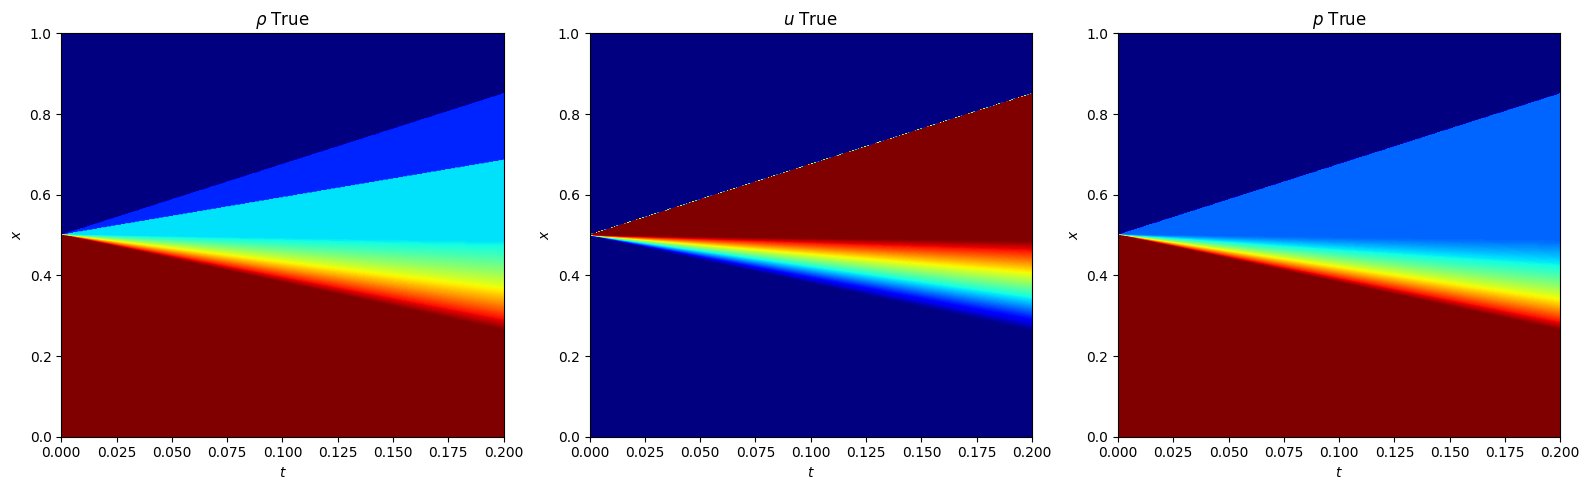

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,5))

ax[0].contourf(T, X, rho_ref, cmap="jet", levels=200)
ax[0].set_title(r"$\rho$ True")

ax[1].contourf(T, X, u_ref, cmap="jet", levels=200)
ax[1].set_title("$u$ True")

ax[2].contourf(T, X, p_ref, cmap="jet", levels=200)
ax[2].set_title("$p$ True")

for axx in ax:
    axx.set_xlabel("$t$")
    axx.set_ylabel("$x$")

plt.tight_layout()
plt.show()

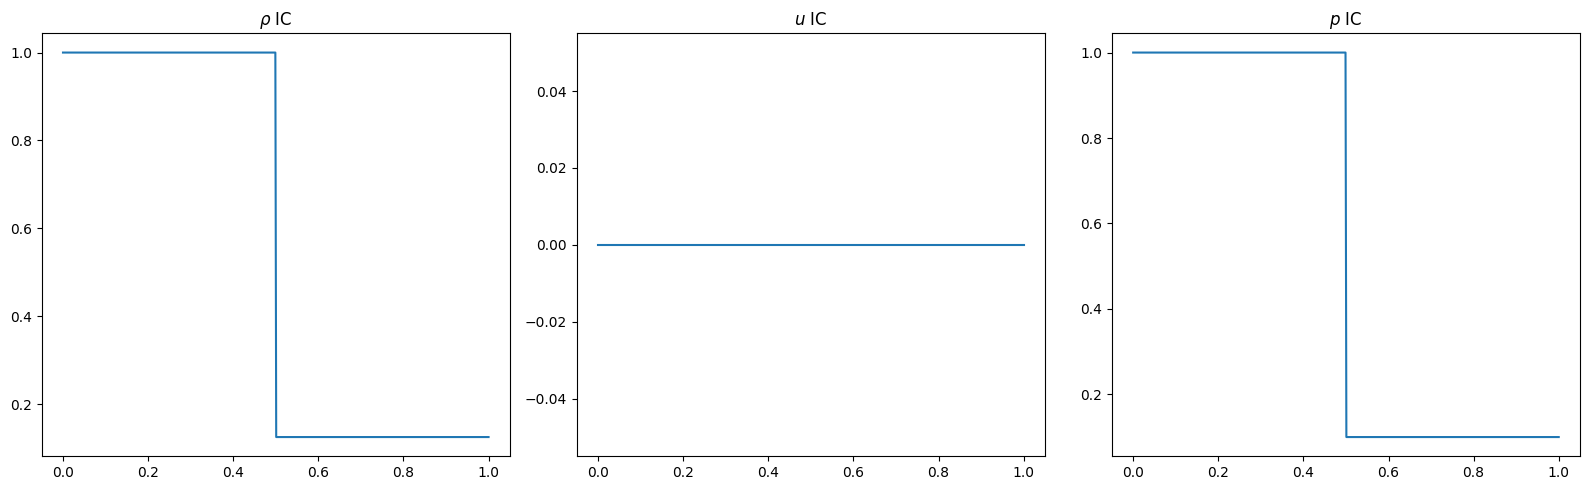

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,5))

ax[0].plot(X[:,0], rho_ref[:,0])
ax[0].set_title(r"$\rho$ IC")

ax[1].plot(X[:,0], u_ref[:,0])
ax[1].set_title("$u$ IC")

ax[2].plot(X[:,0], p_ref[:,0])
ax[2].set_title("$p$ IC")

plt.tight_layout()
plt.show()